Saved: figs\frozenlake_2x2_panel.pdf
Saved: figs\frozenlake_2x2_panel.png


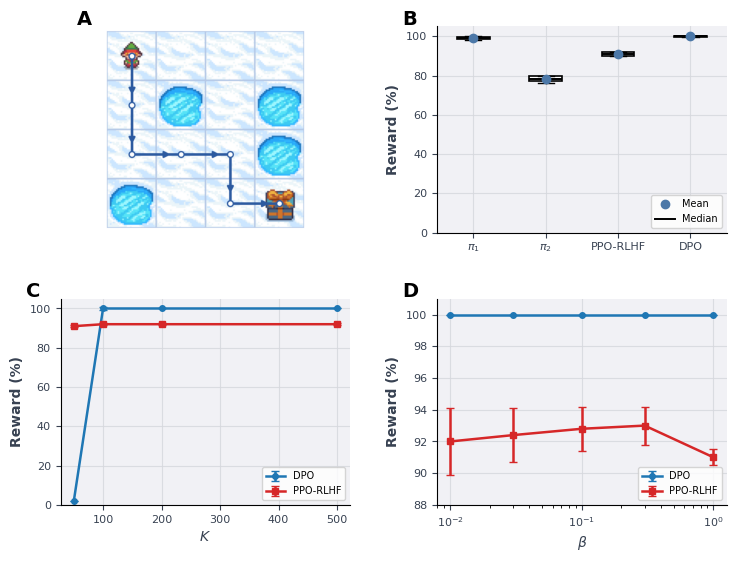

Saved: figs\cartpole_2x2_panel.pdf
Saved: figs\cartpole_2x2_panel.png


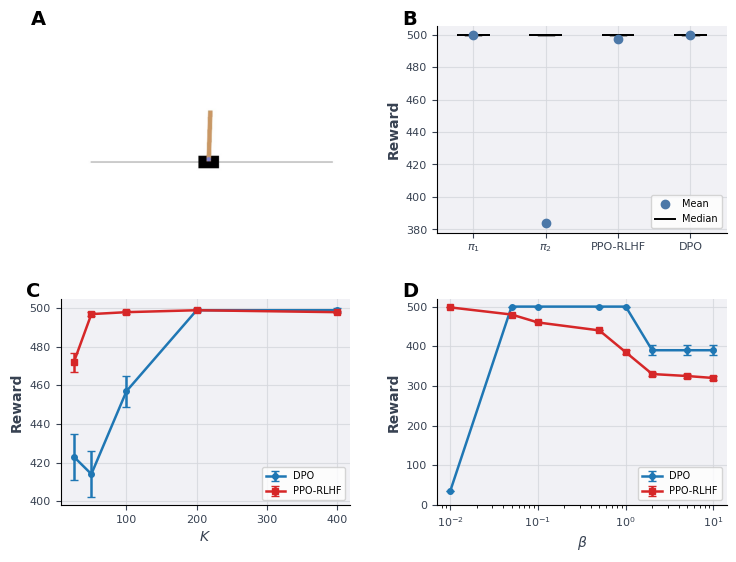

Saved: figs\acrobot_2x2_panel.pdf
Saved: figs\acrobot_2x2_panel.png


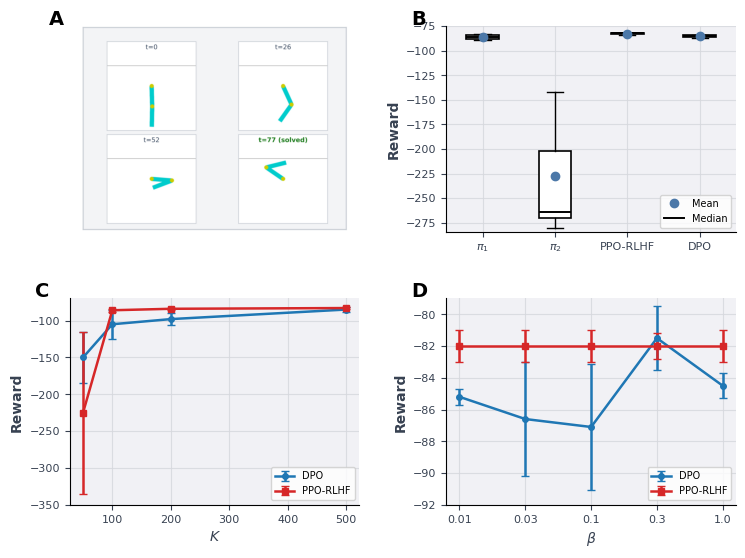

Saved: figs\pendulum_2x2_panel.pdf
Saved: figs\pendulum_2x2_panel.png


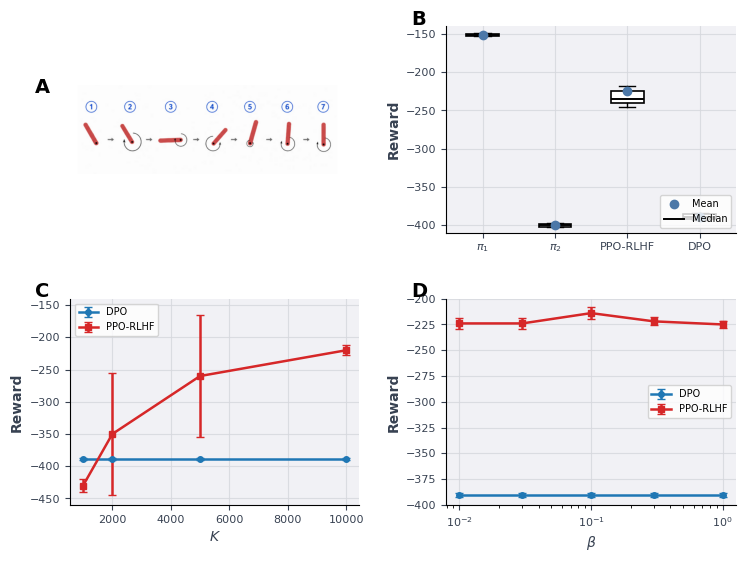

Saved: figs\mountaincarcontinuous_2x2_panel.pdf
Saved: figs\mountaincarcontinuous_2x2_panel.png


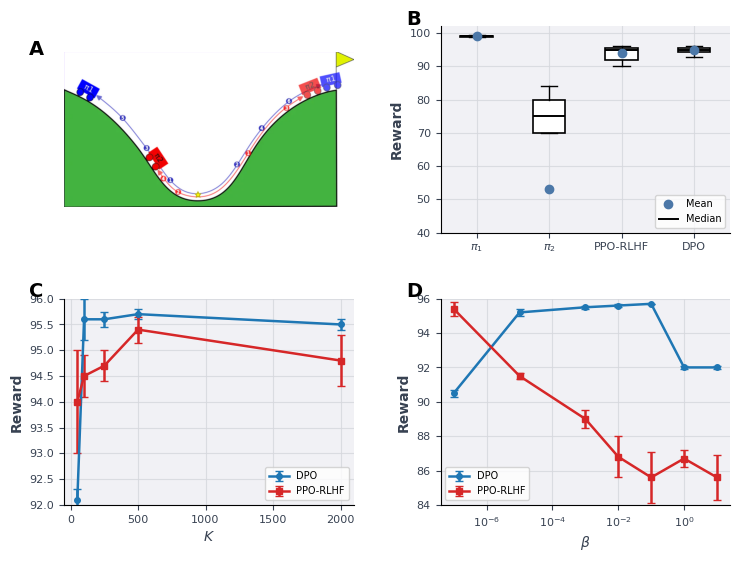

Saved combined PDF: figs\all_2x2_panels.pdf


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

# ============================================================
# Expected image files in notebook folder:
# a1.png = FrozenLake
# a2.png = CartPole
# a3.png = Acrobot
# a4.png = Pendulum
# a5.png = MountainCarContinuous
# ============================================================

OUT_DIR = Path("figs")
OUT_DIR.mkdir(exist_ok=True)

DPO_COLOR = "#1f77b4"
PPO_COLOR = "#d62728"
MEAN_COLOR = "#4c78a8"

PANELS = [
    {
        "name": "frozenlake",
        "a_image": "a1.png",
        "ylabel": "Reward (%)",
        "B_ylim": (0, 105),
        "C_ylim": (0, 105),
        "D_ylim": (88, 101),

        "B": {
            r"$\pi_1$": dict(mean=99.0, med=99.0, q1=98.5, q3=99.5, whislo=98.0, whishi=100.0),
            r"$\pi_2$": dict(mean=78.0, med=78.0, q1=77.0, q3=80.0, whislo=76.0, whishi=80.0),
            "PPO-RLHF": dict(mean=91.0, med=91.0, q1=90.0, q3=92.0, whislo=90.0, whishi=92.0),
            "DPO": dict(mean=100.0, med=100.0, q1=99.5, q3=100.0, whislo=99.5, whishi=100.0),
        },

        "K": {
            "x": [50, 100, 200, 500],
            "DPO": dict(y=[2, 100, 100, 100], err=[0, 1, 0, 0]),
            "PPO-RLHF": dict(y=[91, 92, 92, 92], err=[0.5, 0.5, 0.5, 0.5]),
        },

        "beta": {
            "x": [0.01, 0.03, 0.1, 0.3, 1.0],
            "logx": True,
            "DPO": dict(y=[100, 100, 100, 100, 100], err=[0, 0, 0, 0, 0]),
            "PPO-RLHF": dict(y=[92.0, 92.4, 92.8, 93.0, 91.0], err=[2.1, 1.7, 1.4, 1.2, 0.5]),
        },
    },

    {
        "name": "cartpole",
        "a_image": "a2.png",
        "ylabel": "Reward",
        "B_ylim": (378, 505),
        "C_ylim": (398, 505),
        "D_ylim": (0, 520),

        # FIXED to match your screenshot:
        # pi2 mean marker ~384, median line ~500.
        "B": {
            r"$\pi_1$": dict(mean=500.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
            r"$\pi_2$": dict(mean=384.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
            "PPO-RLHF": dict(mean=497.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
            "DPO": dict(mean=500.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
        },

        "K": {
            "x": [25, 50, 100, 200, 400],
            "DPO": dict(y=[423, 414, 457, 499, 499], err=[12, 12, 8, 1, 1]),
            "PPO-RLHF": dict(y=[472, 497, 498, 499, 498], err=[5, 1, 1, 0.5, 0.5]),
        },

        "beta": {
            "x": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
            "logx": True,
            "DPO": dict(y=[35, 500, 500, 500, 500, 390, 390, 390], err=[0, 0, 0, 0, 0, 12, 12, 12]),
            "PPO-RLHF": dict(y=[498, 480, 460, 440, 385, 330, 325, 320], err=[0, 0, 0, 0, 5, 5, 5, 5]),
        },
    },

    {
        "name": "acrobot",
        "a_image": "a3.png",
        "ylabel": "Reward",
        "B_ylim": (-285, -75),
        "C_ylim": (-350, -70),
        "D_ylim": (-92, -79),

        # FIXED to match Acrobot B from the report:
        # negative values, pi2 mean around -228, median around -264.
        "B": {
            r"$\pi_1$": dict(mean=-86.0, med=-86.0, q1=-88.0, q3=-84.0, whislo=-89.0, whishi=-83.0),
            r"$\pi_2$": dict(mean=-228.0, med=-264.0, q1=-270.0, q3=-202.0, whislo=-280.0, whishi=-142.0),
            "PPO-RLHF": dict(mean=-82.7, med=-82.0, q1=-83.0, q3=-82.0, whislo=-84.0, whishi=-81.5),
            "DPO": dict(mean=-85.1, med=-85.0, q1=-86.0, q3=-84.0, whislo=-86.5, whishi=-83.5),
        },

        "K": {
            "x": [50, 100, 200, 500],
            "DPO": dict(y=[-150, -105, -98, -85], err=[35, 20, 8, 3]),
            "PPO-RLHF": dict(y=[-225, -86, -84, -83], err=[110, 2, 1.5, 1]),
        },

        "beta": {
            "x": [0.01, 0.03, 0.1, 0.3, 1.0],
            "categorical_x": True,
            "DPO": dict(y=[-85.2, -86.6, -87.1, -81.5, -84.5], err=[0.5, 3.6, 4.0, 2.0, 0.8]),
            "PPO-RLHF": dict(y=[-82.0, -82.0, -82.0, -82.0, -82.0], err=[1.0, 1.0, 1.0, 0.8, 1.0]),
        },
    },

    {
        "name": "pendulum",
        "a_image": "a4.png",
        "ylabel": "Reward",
        "B_ylim": (-410, -140),
        "C_ylim": (-460, -140),
        "D_ylim": (-400, -200),

        "B": {
            r"$\pi_1$": dict(mean=-151.0, med=-151.0, q1=-152.0, q3=-150.0, whislo=-153.0, whishi=-149.0),
            r"$\pi_2$": dict(mean=-400.0, med=-400.0, q1=-402.0, q3=-398.0, whislo=-403.0, whishi=-397.0),
            "PPO-RLHF": dict(mean=-224.0, med=-235.0, q1=-240.0, q3=-225.0, whislo=-245.0, whishi=-218.0),
            "DPO": dict(mean=-389.0, med=-389.0, q1=-392.0, q3=-386.0, whislo=-394.0, whishi=-384.0),
        },

        "K": {
            "x": [1000, 2000, 5000, 10000],
            "DPO": dict(y=[-389, -389, -389, -389], err=[2, 2, 2, 2]),
            "PPO-RLHF": dict(y=[-430, -350, -260, -220], err=[10, 95, 95, 8]),
        },

        "beta": {
            "x": [0.01, 0.03, 0.1, 0.3, 1.0],
            "logx": True,
            "DPO": dict(y=[-390, -390, -390, -390, -390], err=[2, 2, 2, 2, 2]),
            "PPO-RLHF": dict(y=[-224, -224, -214, -222, -225], err=[5, 5, 6, 4, 3]),
        },
    },

    {
        "name": "mountaincarcontinuous",
        "a_image": "a5.png",
        "ylabel": "Reward",
        "B_ylim": (40, 102),
        "C_ylim": (92, 96),
        "D_ylim": (84, 96),

        "B": {
            r"$\pi_1$": dict(mean=99.0, med=99.0, q1=98.8, q3=99.2, whislo=98.7, whishi=99.3),
            r"$\pi_2$": dict(mean=53.0, med=75.0, q1=70.0, q3=80.0, whislo=70.0, whishi=84.0),
            "PPO-RLHF": dict(mean=94.0, med=95.0, q1=92.0, q3=95.5, whislo=90.0, whishi=96.0),
            "DPO": dict(mean=95.0, med=95.0, q1=94.2, q3=95.6, whislo=92.8, whishi=96.0),
        },

        "K": {
            "x": [50, 100, 250, 500, 2000],
            "DPO": dict(y=[92.1, 95.6, 95.6, 95.7, 95.5], err=[0.2, 0.4, 0.15, 0.1, 0.1]),
            "PPO-RLHF": dict(y=[94.0, 94.5, 94.7, 95.4, 94.8], err=[1.0, 0.4, 0.3, 0.25, 0.5]),
        },

        "beta": {
            "x": [1e-7, 1e-5, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
            "logx": True,
            "DPO": dict(y=[90.5, 95.2, 95.5, 95.6, 95.7, 92.0, 92.0], err=[0.2, 0.2, 0.1, 0.1, 0.0, 0.1, 0.1]),
            "PPO-RLHF": dict(y=[95.4, 91.5, 89.0, 86.8, 85.6, 86.7, 85.6], err=[0.4, 0.2, 0.5, 1.2, 1.5, 0.5, 1.3]),
        },
    },
]

def clean_label(label):
    if label in ["RLHF-PPO", "RLHF/PPO", "PPO/RLHF"]:
        return "PPO-RLHF"
    return label

def style_axis(ax):
    ax.set_facecolor("#f1f1f5")
    ax.grid(True, color="#d5d7dc", linewidth=0.8, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=8, colors="#374151")
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_color("#374151")
    ax.yaxis.label.set_color("#374151")

def plot_image_panel(ax, image_path):
    image_path = Path(image_path)
    if image_path.exists():
        img = plt.imread(image_path)
        ax.imshow(img)
        ax.axis("off")
    else:
        ax.text(
            0.5, 0.5,
            f"Missing image:\n{image_path}",
            ha="center",
            va="center",
            fontsize=10,
            transform=ax.transAxes,
        )
        ax.axis("off")

def plot_box_panel(ax, box_data, ylabel, ylim=None):
    stats = []
    for label, values in box_data.items():
        stats.append({
            "label": clean_label(label),
            "mean": values["mean"],
            "med": values["med"],
            "q1": values["q1"],
            "q3": values["q3"],
            "whislo": values["whislo"],
            "whishi": values["whishi"],
            "fliers": values.get("fliers", []),
        })

    ax.bxp(
        stats,
        showmeans=True,
        patch_artist=True,
        widths=0.45,
        meanprops=dict(
            marker="o",
            markerfacecolor=MEAN_COLOR,
            markeredgecolor=MEAN_COLOR,
            markersize=6,
        ),
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor=MEAN_COLOR,
            markeredgecolor=MEAN_COLOR,
            markersize=4,
            alpha=0.9,
        ),
    )

    ax.set_ylabel(ylabel, fontsize=10, fontweight="bold")

    if ylim is not None:
        ax.set_ylim(*ylim)

    mean_handle = Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=MEAN_COLOR,
        markeredgecolor=MEAN_COLOR,
        markersize=6,
        label="Mean",
    )
    median_handle = Line2D(
        [0], [0],
        color="black",
        linewidth=1.4,
        label="Median",
    )

    ax.legend(handles=[mean_handle, median_handle], frameon=True, fontsize=7, loc="lower right")
    style_axis(ax)

def plot_sweep(ax, sweep, xlabel, ylabel, ylim=None):
    raw_x = sweep["x"]

    if sweep.get("categorical_x", False):
        x = np.arange(len(raw_x))
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in raw_x])
    else:
        x = np.asarray(raw_x, dtype=float)
        if sweep.get("logx", False):
            ax.set_xscale("log")

    for label, color, marker in [
        ("DPO", DPO_COLOR, "o"),
        ("PPO-RLHF", PPO_COLOR, "s"),
    ]:
        y = np.asarray(sweep[label]["y"], dtype=float)
        err = np.asarray(sweep[label]["err"], dtype=float)

        ax.errorbar(
            x,
            y,
            yerr=err,
            color=color,
            marker=marker,
            linewidth=1.8,
            markersize=4,
            capsize=3,
            label=clean_label(label),
        )

    ax.set_xlabel(xlabel, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10, fontweight="bold")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(frameon=True, fontsize=7, loc="best")
    style_axis(ax)

def add_panel_letters(axes):
    for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):
        ax.text(
            -0.12,
            1.08,
            letter,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
            color="black",
        )

def make_panel(panel, save=True, show=True):
    fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.5), constrained_layout=False)

    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.10,
        top=0.97,
        wspace=0.30,
        hspace=0.32,
    )

    plot_image_panel(axes[0, 0], panel["a_image"])

    plot_box_panel(
        axes[0, 1],
        panel["B"],
        ylabel=panel["ylabel"],
        ylim=panel.get("B_ylim"),
    )

    plot_sweep(
        axes[1, 0],
        panel["K"],
        xlabel=r"$K$",
        ylabel=panel["ylabel"],
        ylim=panel.get("C_ylim"),
    )

    plot_sweep(
        axes[1, 1],
        panel["beta"],
        xlabel=r"$\beta$",
        ylabel=panel["ylabel"],
        ylim=panel.get("D_ylim"),
    )

    add_panel_letters(axes)

    if save:
        out_pdf = OUT_DIR / f"{panel['name']}_2x2_panel.pdf"
        out_png = OUT_DIR / f"{panel['name']}_2x2_panel.png"
        fig.savefig(out_pdf, bbox_inches="tight")
        fig.savefig(out_png, bbox_inches="tight", dpi=300)
        print(f"Saved: {out_pdf}")
        print(f"Saved: {out_png}")

    if show:
        plt.show()

    return fig

for panel in PANELS:
    fig = make_panel(panel, save=True, show=True)
    plt.close(fig)

combined_pdf = OUT_DIR / "all_2x2_panels.pdf"

with PdfPages(combined_pdf) as pdf:
    for panel in PANELS:
        fig = make_panel(panel, save=False, show=False)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Saved combined PDF: {combined_pdf}")

Saved subplot: figs\separate\frozenlake_A.pdf
Saved subplot: figs\separate\frozenlake_A.png
Saved subplot: figs\separate\frozenlake_B.pdf
Saved subplot: figs\separate\frozenlake_B.png
Saved subplot: figs\separate\frozenlake_C.pdf
Saved subplot: figs\separate\frozenlake_C.png
Saved subplot: figs\separate\frozenlake_D.pdf
Saved subplot: figs\separate\frozenlake_D.png
Saved: figs\frozenlake_2x2_panel.pdf
Saved: figs\frozenlake_2x2_panel.png


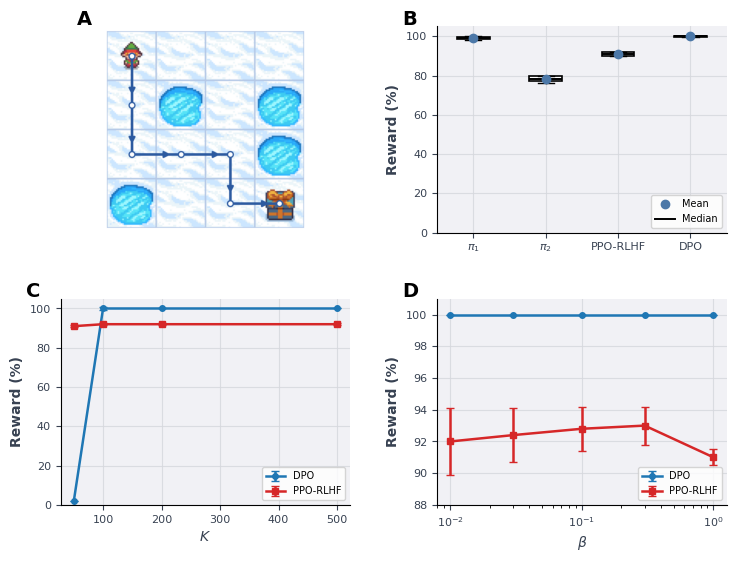

Saved subplot: figs\separate\cartpole_A.pdf
Saved subplot: figs\separate\cartpole_A.png
Saved subplot: figs\separate\cartpole_B.pdf
Saved subplot: figs\separate\cartpole_B.png
Saved subplot: figs\separate\cartpole_C.pdf
Saved subplot: figs\separate\cartpole_C.png
Saved subplot: figs\separate\cartpole_D.pdf
Saved subplot: figs\separate\cartpole_D.png
Saved: figs\cartpole_2x2_panel.pdf
Saved: figs\cartpole_2x2_panel.png


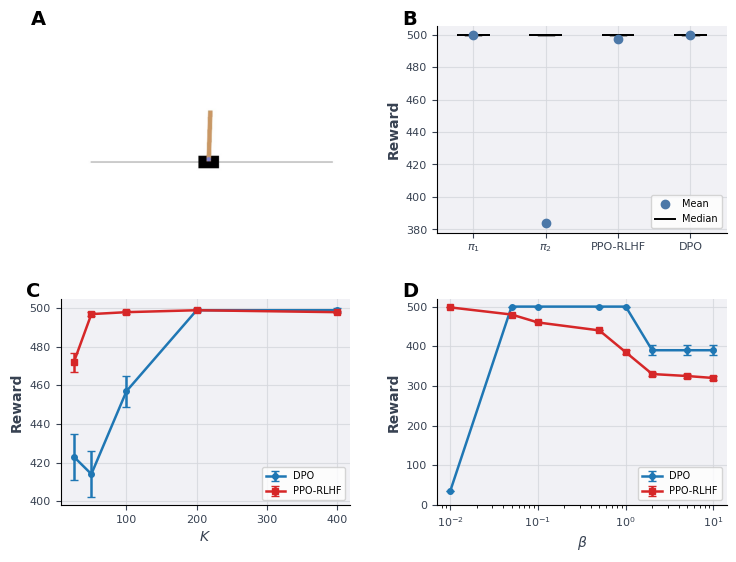

Saved subplot: figs\separate\acrobot_A.pdf
Saved subplot: figs\separate\acrobot_A.png
Saved subplot: figs\separate\acrobot_B.pdf
Saved subplot: figs\separate\acrobot_B.png
Saved subplot: figs\separate\acrobot_C.pdf
Saved subplot: figs\separate\acrobot_C.png
Saved subplot: figs\separate\acrobot_D.pdf
Saved subplot: figs\separate\acrobot_D.png
Saved: figs\acrobot_2x2_panel.pdf
Saved: figs\acrobot_2x2_panel.png


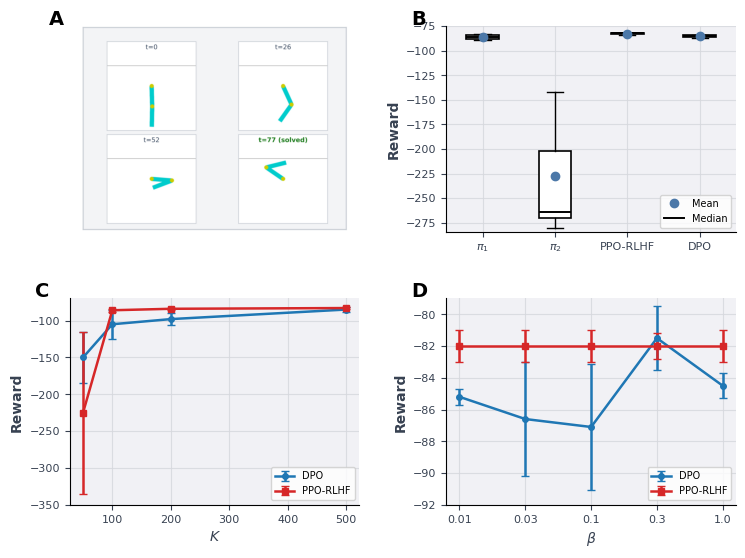

Saved subplot: figs\separate\pendulum_A.pdf
Saved subplot: figs\separate\pendulum_A.png
Saved subplot: figs\separate\pendulum_B.pdf
Saved subplot: figs\separate\pendulum_B.png
Saved subplot: figs\separate\pendulum_C.pdf
Saved subplot: figs\separate\pendulum_C.png
Saved subplot: figs\separate\pendulum_D.pdf
Saved subplot: figs\separate\pendulum_D.png
Saved: figs\pendulum_2x2_panel.pdf
Saved: figs\pendulum_2x2_panel.png


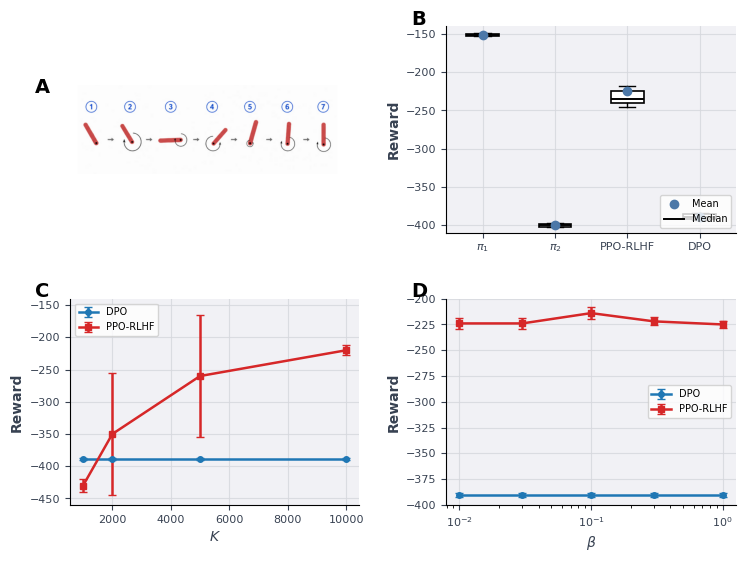

Saved subplot: figs\separate\mountaincarcontinuous_A.pdf
Saved subplot: figs\separate\mountaincarcontinuous_A.png
Saved subplot: figs\separate\mountaincarcontinuous_B.pdf
Saved subplot: figs\separate\mountaincarcontinuous_B.png
Saved subplot: figs\separate\mountaincarcontinuous_C.pdf
Saved subplot: figs\separate\mountaincarcontinuous_C.png
Saved subplot: figs\separate\mountaincarcontinuous_D.pdf
Saved subplot: figs\separate\mountaincarcontinuous_D.png
Saved: figs\mountaincarcontinuous_2x2_panel.pdf
Saved: figs\mountaincarcontinuous_2x2_panel.png


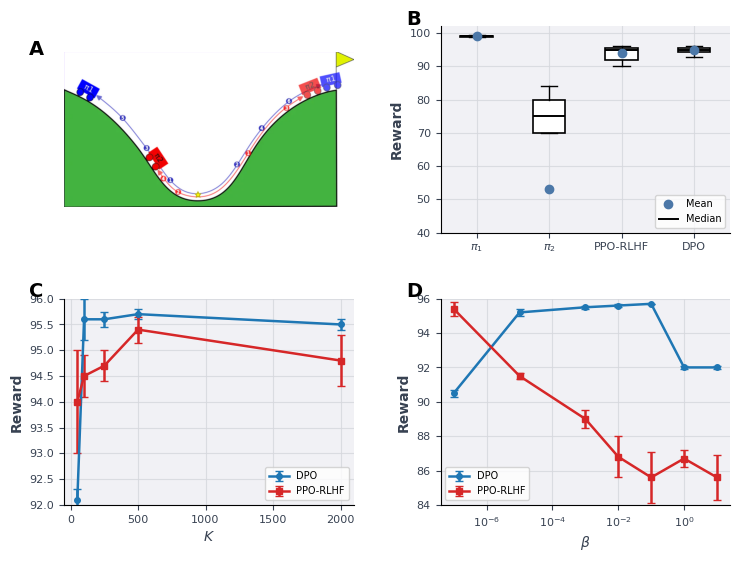

Saved combined PDF: figs\all_2x2_panels.pdf
Saved separate subplot files in: figs\separate


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D

# ============================================================
# Expected image files in notebook folder:
# a1.png = FrozenLake
# a2.png = CartPole
# a3.png = Acrobot
# a4.png = Pendulum
# a5.png = MountainCarContinuous
# ============================================================

OUT_DIR = Path("figs")
OUT_DIR.mkdir(exist_ok=True)

SEPARATE_DIR = OUT_DIR / "separate"
SEPARATE_DIR.mkdir(exist_ok=True)

DPO_COLOR = "#1f77b4"
PPO_COLOR = "#d62728"
MEAN_COLOR = "#4c78a8"

PANELS = [
    {
        "name": "frozenlake",
        "a_image": "a1.png",
        "ylabel": "Reward (%)",
        "B_ylim": (0, 105),
        "C_ylim": (0, 105),
        "D_ylim": (88, 101),

        "B": {
            r"$\pi_1$": dict(mean=99.0, med=99.0, q1=98.5, q3=99.5, whislo=98.0, whishi=100.0),
            r"$\pi_2$": dict(mean=78.0, med=78.0, q1=77.0, q3=80.0, whislo=76.0, whishi=80.0),
            "PPO-RLHF": dict(mean=91.0, med=91.0, q1=90.0, q3=92.0, whislo=90.0, whishi=92.0),
            "DPO": dict(mean=100.0, med=100.0, q1=99.5, q3=100.0, whislo=99.5, whishi=100.0),
        },

        "K": {
            "x": [50, 100, 200, 500],
            "DPO": dict(y=[2, 100, 100, 100], err=[0, 1, 0, 0]),
            "PPO-RLHF": dict(y=[91, 92, 92, 92], err=[0.5, 0.5, 0.5, 0.5]),
        },

        "beta": {
            "x": [0.01, 0.03, 0.1, 0.3, 1.0],
            "logx": True,
            "DPO": dict(y=[100, 100, 100, 100, 100], err=[0, 0, 0, 0, 0]),
            "PPO-RLHF": dict(y=[92.0, 92.4, 92.8, 93.0, 91.0], err=[2.1, 1.7, 1.4, 1.2, 0.5]),
        },
    },

    {
        "name": "cartpole",
        "a_image": "a2.png",
        "ylabel": "Reward",
        "B_ylim": (378, 505),
        "C_ylim": (398, 505),
        "D_ylim": (0, 520),

        "B": {
            r"$\pi_1$": dict(mean=500.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
            r"$\pi_2$": dict(mean=384.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
            "PPO-RLHF": dict(mean=497.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
            "DPO": dict(mean=500.0, med=500.0, q1=500.0, q3=500.0, whislo=500.0, whishi=500.0),
        },

        "K": {
            "x": [25, 50, 100, 200, 400],
            "DPO": dict(y=[423, 414, 457, 499, 499], err=[12, 12, 8, 1, 1]),
            "PPO-RLHF": dict(y=[472, 497, 498, 499, 498], err=[5, 1, 1, 0.5, 0.5]),
        },

        "beta": {
            "x": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
            "logx": True,
            "DPO": dict(y=[35, 500, 500, 500, 500, 390, 390, 390], err=[0, 0, 0, 0, 0, 12, 12, 12]),
            "PPO-RLHF": dict(y=[498, 480, 460, 440, 385, 330, 325, 320], err=[0, 0, 0, 0, 5, 5, 5, 5]),
        },
    },

    {
        "name": "acrobot",
        "a_image": "a3.png",
        "ylabel": "Reward",
        "B_ylim": (-285, -75),
        "C_ylim": (-350, -70),
        "D_ylim": (-92, -79),

        "B": {
            r"$\pi_1$": dict(mean=-86.0, med=-86.0, q1=-88.0, q3=-84.0, whislo=-89.0, whishi=-83.0),
            r"$\pi_2$": dict(mean=-228.0, med=-264.0, q1=-270.0, q3=-202.0, whislo=-280.0, whishi=-142.0),
            "PPO-RLHF": dict(mean=-82.7, med=-82.0, q1=-83.0, q3=-82.0, whislo=-84.0, whishi=-81.5),
            "DPO": dict(mean=-85.1, med=-85.0, q1=-86.0, q3=-84.0, whislo=-86.5, whishi=-83.5),
        },

        "K": {
            "x": [50, 100, 200, 500],
            "DPO": dict(y=[-150, -105, -98, -85], err=[35, 20, 8, 3]),
            "PPO-RLHF": dict(y=[-225, -86, -84, -83], err=[110, 2, 1.5, 1]),
        },

        "beta": {
            "x": [0.01, 0.03, 0.1, 0.3, 1.0],
            "categorical_x": True,
            "DPO": dict(y=[-85.2, -86.6, -87.1, -81.5, -84.5], err=[0.5, 3.6, 4.0, 2.0, 0.8]),
            "PPO-RLHF": dict(y=[-82.0, -82.0, -82.0, -82.0, -82.0], err=[1.0, 1.0, 1.0, 0.8, 1.0]),
        },
    },

    {
        "name": "pendulum",
        "a_image": "a4.png",
        "ylabel": "Reward",
        "B_ylim": (-410, -140),
        "C_ylim": (-460, -140),
        "D_ylim": (-400, -200),

        "B": {
            r"$\pi_1$": dict(mean=-151.0, med=-151.0, q1=-152.0, q3=-150.0, whislo=-153.0, whishi=-149.0),
            r"$\pi_2$": dict(mean=-400.0, med=-400.0, q1=-402.0, q3=-398.0, whislo=-403.0, whishi=-397.0),
            "PPO-RLHF": dict(mean=-224.0, med=-235.0, q1=-240.0, q3=-225.0, whislo=-245.0, whishi=-218.0),
            "DPO": dict(mean=-389.0, med=-389.0, q1=-392.0, q3=-386.0, whislo=-394.0, whishi=-384.0),
        },

        "K": {
            "x": [1000, 2000, 5000, 10000],
            "DPO": dict(y=[-389, -389, -389, -389], err=[2, 2, 2, 2]),
            "PPO-RLHF": dict(y=[-430, -350, -260, -220], err=[10, 95, 95, 8]),
        },

        "beta": {
            "x": [0.01, 0.03, 0.1, 0.3, 1.0],
            "logx": True,
            "DPO": dict(y=[-390, -390, -390, -390, -390], err=[2, 2, 2, 2, 2]),
            "PPO-RLHF": dict(y=[-224, -224, -214, -222, -225], err=[5, 5, 6, 4, 3]),
        },
    },

    {
        "name": "mountaincarcontinuous",
        "a_image": "a5.png",
        "ylabel": "Reward",
        "B_ylim": (40, 102),
        "C_ylim": (92, 96),
        "D_ylim": (84, 96),

        "B": {
            r"$\pi_1$": dict(mean=99.0, med=99.0, q1=98.8, q3=99.2, whislo=98.7, whishi=99.3),
            r"$\pi_2$": dict(mean=53.0, med=75.0, q1=70.0, q3=80.0, whislo=70.0, whishi=84.0),
            "PPO-RLHF": dict(mean=94.0, med=95.0, q1=92.0, q3=95.5, whislo=90.0, whishi=96.0),
            "DPO": dict(mean=95.0, med=95.0, q1=94.2, q3=95.6, whislo=92.8, whishi=96.0),
        },

        "K": {
            "x": [50, 100, 250, 500, 2000],
            "DPO": dict(y=[92.1, 95.6, 95.6, 95.7, 95.5], err=[0.2, 0.4, 0.15, 0.1, 0.1]),
            "PPO-RLHF": dict(y=[94.0, 94.5, 94.7, 95.4, 94.8], err=[1.0, 0.4, 0.3, 0.25, 0.5]),
        },

        "beta": {
            "x": [1e-7, 1e-5, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
            "logx": True,
            "DPO": dict(y=[90.5, 95.2, 95.5, 95.6, 95.7, 92.0, 92.0], err=[0.2, 0.2, 0.1, 0.1, 0.0, 0.1, 0.1]),
            "PPO-RLHF": dict(y=[95.4, 91.5, 89.0, 86.8, 85.6, 86.7, 85.6], err=[0.4, 0.2, 0.5, 1.2, 1.5, 0.5, 1.3]),
        },
    },
]

def clean_label(label):
    if label in ["RLHF-PPO", "RLHF/PPO", "PPO/RLHF"]:
        return "PPO-RLHF"
    return label

def style_axis(ax):
    ax.set_facecolor("#f1f1f5")
    ax.grid(True, color="#d5d7dc", linewidth=0.8, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=8, colors="#374151")
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
    ax.xaxis.label.set_color("#374151")
    ax.yaxis.label.set_color("#374151")

def plot_image_panel(ax, image_path):
    image_path = Path(image_path)
    if image_path.exists():
        img = plt.imread(image_path)
        ax.imshow(img)
        ax.axis("off")
    else:
        ax.text(
            0.5, 0.5,
            f"Missing image:\n{image_path}",
            ha="center",
            va="center",
            fontsize=10,
            transform=ax.transAxes,
        )
        ax.axis("off")

def plot_box_panel(ax, box_data, ylabel, ylim=None):
    stats = []
    for label, values in box_data.items():
        stats.append({
            "label": clean_label(label),
            "mean": values["mean"],
            "med": values["med"],
            "q1": values["q1"],
            "q3": values["q3"],
            "whislo": values["whislo"],
            "whishi": values["whishi"],
            "fliers": values.get("fliers", []),
        })

    ax.bxp(
        stats,
        showmeans=True,
        patch_artist=True,
        widths=0.45,
        meanprops=dict(
            marker="o",
            markerfacecolor=MEAN_COLOR,
            markeredgecolor=MEAN_COLOR,
            markersize=6,
        ),
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor=MEAN_COLOR,
            markeredgecolor=MEAN_COLOR,
            markersize=4,
            alpha=0.9,
        ),
    )

    ax.set_ylabel(ylabel, fontsize=10, fontweight="bold")
    if ylim is not None:
        ax.set_ylim(*ylim)

    mean_handle = Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=MEAN_COLOR,
        markeredgecolor=MEAN_COLOR,
        markersize=6,
        label="Mean",
    )
    median_handle = Line2D(
        [0], [0],
        color="black",
        linewidth=1.4,
        label="Median",
    )

    ax.legend(handles=[mean_handle, median_handle], frameon=True, fontsize=7, loc="lower right")
    style_axis(ax)

def plot_sweep(ax, sweep, xlabel, ylabel, ylim=None):
    raw_x = sweep["x"]

    if sweep.get("categorical_x", False):
        x = np.arange(len(raw_x))
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in raw_x])
    else:
        x = np.asarray(raw_x, dtype=float)
        if sweep.get("logx", False):
            ax.set_xscale("log")

    for label, color, marker in [
        ("DPO", DPO_COLOR, "o"),
        ("PPO-RLHF", PPO_COLOR, "s"),
    ]:
        y = np.asarray(sweep[label]["y"], dtype=float)
        err = np.asarray(sweep[label]["err"], dtype=float)

        ax.errorbar(
            x,
            y,
            yerr=err,
            color=color,
            marker=marker,
            linewidth=1.8,
            markersize=4,
            capsize=3,
            label=clean_label(label),
        )

    ax.set_xlabel(xlabel, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10, fontweight="bold")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(frameon=True, fontsize=7, loc="best")
    style_axis(ax)

def add_panel_letters(axes):
    for ax, letter in zip(axes.flat, ["A", "B", "C", "D"]):
        ax.text(
            -0.12,
            1.08,
            letter,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            ha="left",
            va="top",
            color="black",
        )

def save_axes_separately(fig, axes, base_name, out_dir):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    labels = ["A", "B", "C", "D"]

    for ax, label in zip(axes.flat, labels):
        bbox = ax.get_tightbbox(renderer).expanded(1.03, 1.08)
        bbox_inches = bbox.transformed(fig.dpi_scale_trans.inverted())

        out_pdf = out_dir / f"{base_name}_{label}.pdf"
        out_png = out_dir / f"{base_name}_{label}.png"

        fig.savefig(out_pdf, bbox_inches=bbox_inches)
        fig.savefig(out_png, bbox_inches=bbox_inches, dpi=300)

        print(f"Saved subplot: {out_pdf}")
        print(f"Saved subplot: {out_png}")

def make_panel(panel, save=True, show=True, save_subplots=True):
    fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.5), constrained_layout=False)

    plt.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.10,
        top=0.97,
        wspace=0.30,
        hspace=0.32,
    )

    plot_image_panel(axes[0, 0], panel["a_image"])

    plot_box_panel(
        axes[0, 1],
        panel["B"],
        ylabel=panel["ylabel"],
        ylim=panel.get("B_ylim"),
    )

    plot_sweep(
        axes[1, 0],
        panel["K"],
        xlabel=r"$K$",
        ylabel=panel["ylabel"],
        ylim=panel.get("C_ylim"),
    )

    plot_sweep(
        axes[1, 1],
        panel["beta"],
        xlabel=r"$\beta$",
        ylabel=panel["ylabel"],
        ylim=panel.get("D_ylim"),
    )

    # Save separate A/B/C/D panels BEFORE adding letters
    if save_subplots:
        save_axes_separately(fig, axes, panel["name"], SEPARATE_DIR)

    # Add letters only for the full 2x2 panel
    add_panel_letters(axes)

    if save:
        out_pdf = OUT_DIR / f"{panel['name']}_2x2_panel.pdf"
        out_png = OUT_DIR / f"{panel['name']}_2x2_panel.png"

        fig.savefig(out_pdf, bbox_inches="tight")
        fig.savefig(out_png, bbox_inches="tight", dpi=300)

        print(f"Saved: {out_pdf}")
        print(f"Saved: {out_png}")

    if show:
        plt.show()

    return fig

# Save all full 2x2 panels + all individual A/B/C/D subplots
for panel in PANELS:
    fig = make_panel(panel, save=True, show=True, save_subplots=True)
    plt.close(fig)

# Save one combined multi-page PDF with the full 2x2 panels
combined_pdf = OUT_DIR / "all_2x2_panels.pdf"
with PdfPages(combined_pdf) as pdf:
    for panel in PANELS:
        fig = make_panel(panel, save=False, show=False, save_subplots=False)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print(f"Saved combined PDF: {combined_pdf}")
print(f"Saved separate subplot files in: {SEPARATE_DIR}")